***Machine Learning Project***

***Phase 01 — Student Dropout Prediction***

***1- Problem Statement***

Student dropout is a major challenge for educational institutions because students may leave their studies due to poor academic performance, financial difficulties, demographic factors, or other socioeconomic and enrollment-related issues.

The objective of this project is to develop a **Machine Learning classification model using Logistic Regression** that can identify whether a student is at risk of dropping out based on their available academic, demographic, socioeconomic, and enrollment-related information.

The model can help educational institutions identify students who may need additional support and take preventive action before they drop out.

***2- ML Problem Type***

Problem Type: **Classification**

Why?

Because the model is predicting a category/class, rather than a continuous numerical value.

The model will classify a student into categories such as:

Prediction	Meaning:                                                          
**0**	Student is not at risk of dropping out                                 
**1**	Student is at risk of dropping out

Algorithm: **Logistic Regression**

 ***3- Target Variable***

The target variable is:

***Student Dropout / Dropout Status***

This is the variable that the Machine Learning model will learn to predict.

For a binary classification version:

0 → **Not** **Dropout**   
1 → **Dropout**


***4- Input Features***

The model will use information about the student as input features.          
**Academic Features**

*   Previous academic performance
*   Grades
*   Number of courses
*   Academic results

**Demographic Features**

*   Age
*   Gender
*   Other demographic information available in the dataset

**Socioeconomic Features**

* Financial/background information
* Scholarship or financial support information
* Other socioeconomic factors available in the dataset

**Enrollment Features**

* Enrollment status
* Course/program information
* Semester-related information
* Previous enrollment details

***5- Real World Application***

Educational institutions can use this system to identify students who have a higher risk of dropping out.

For example:

**Student Data**                                                             
     ↓
**ML Model**
     ↓
**Dropout Risk**
     ↓
**High Risk Student**
     ↓
**Additional Support**                                                                                                                                                                                                                            
**If the model identifies a student as high-risk, the institution could provide:**

* Academic counseling
* Extra tutoring
* Financial assistance
* Mentoring
* Student support programs

The goal is not to label students permanently, but to help institutions identify students who may benefit from additional support.


***Phase 02: Find and Collect the Dataset***

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv('/content/student_dropout_dataset_v3.csv')

In [7]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [8]:
df.shape

(10000, 19)

In [9]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')

In [10]:
df.dtypes

,0
Student_ID,int64
Age,float64
Gender,object
Family_Income,float64
Internet_Access,object
Study_Hours_per_Day,float64
Attendance_Rate,float64
Assignment_Delay_Days,int64
Travel_Time_Minutes,float64
Part_Time_Job,object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [12]:
df['Dropout'].value_counts()

,count
Dropout,
0,7646
1,2354


In [13]:
df['Dropout'].value_counts(normalize=True) * 100

,proportion
Dropout,
0,76.46
1,23.54


***Project Phase 3 — Student Dropout Prediction***

In [14]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Family_Income,500
Internet_Access,0
Study_Hours_per_Day,500
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Part_Time_Job,0


In [15]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
Parental_Education,5.11
Family_Income,5.00
Stress_Index,5.00
Study_Hours_per_Day,5.00
Gender,0.00
Student_ID,0.00
Age,0.00
Assignment_Delay_Days,0.00
Travel_Time_Minutes,0.00
Internet_Access,0.00


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.dtypes

,0
Student_ID,int64
Age,float64
Gender,object
Family_Income,float64
Internet_Access,object
Study_Hours_per_Day,float64
Attendance_Rate,float64
Assignment_Delay_Days,int64
Travel_Time_Minutes,float64
Part_Time_Job,object


*# Fill numerical missing values with median*

In [18]:
df['Family_Income'] = df['Family_Income'].fillna(df['Family_Income'].median())
df['Study_Hours_per_Day'] = df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].median())
df['Stress_Index'] = df['Stress_Index'].fillna(df['Stress_Index'].median())

*# Fill numerical missing values with mode*

In [19]:
df['Parental_Education'] = df['Parental_Education'].fillna(df['Parental_Education'].mode()[0])

In [20]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Family_Income,0
Internet_Access,0
Study_Hours_per_Day,0
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Part_Time_Job,0


In [21]:
categorical_cols = [
    'Gender',
    'Internet_Access',
    'Part_Time_Job',
    'Scholarship',
    'Semester',
    'Department',
    'Parental_Education'
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


Gender:
['Male' 'Female']

Internet_Access:
['Yes' 'No']

Part_Time_Job:
['Yes' 'No']

Scholarship:
['No' 'Yes']

Semester:
['Year 1' 'Year 3' 'Year 4' 'Year 2']

Department:
['Arts' 'Engineering' 'CS' 'Business' 'Science']

Parental_Education:
['High School' 'Bachelor' 'Master' 'PhD']


In [22]:
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

df['Internet_Access'] = df['Internet_Access'].map({'No': 0, 'Yes': 1})

df['Part_Time_Job'] = df['Part_Time_Job'].map({'No': 0, 'Yes': 1})

df['Scholarship'] = df['Scholarship'].map({'No': 0, 'Yes': 1})

In [23]:
df[['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship']].head()

,Gender,Internet_Access,Part_Time_Job,Scholarship
0,1,1,1,0
1,1,1,0,0
2,1,1,1,0
3,1,1,0,0
4,0,1,0,0


In [24]:
df = pd.get_dummies(
    df,
    columns=['Semester', 'Department', 'Parental_Education'],
    drop_first=True,
    dtype=int
)

df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,...,Semester_Year 2,Semester_Year 3,Semester_Year 4,Department_Business,Department_CS,Department_Engineering,Department_Science,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD
0,1,22.1,1,25000.0,1,3.36,86.1,2,20.4,1,...,0,0,0,0,0,0,0,1,0,0
1,2,20.7,1,25000.0,1,4.30,68.0,2,44.0,0,...,0,1,0,0,0,1,0,0,0,0
2,3,22.4,1,40183.0,1,4.40,70.9,0,48.9,1,...,0,0,0,0,0,0,0,0,1,0
3,4,24.4,1,29740.5,1,4.00,82.2,2,38.6,0,...,0,0,0,0,1,0,0,1,0,0
4,5,20.5,0,25319.0,1,4.19,75.7,1,23.0,0,...,0,0,1,1,0,0,0,0,0,0


In [25]:
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Object Columns:", df.select_dtypes(include='object').columns.tolist())
print("Final Shape:", df.shape)

Missing Values: 0
Duplicate Rows: 0
Object Columns: []
Final Shape: (10000, 26)


***Project Phase 4 — Student Dropout Prediction***

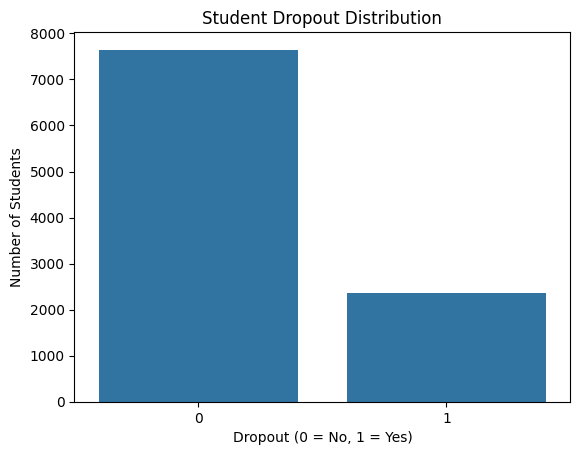

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Dropout', data=df)

plt.title('Student Dropout Distribution')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('Number of Students')
plt.show()

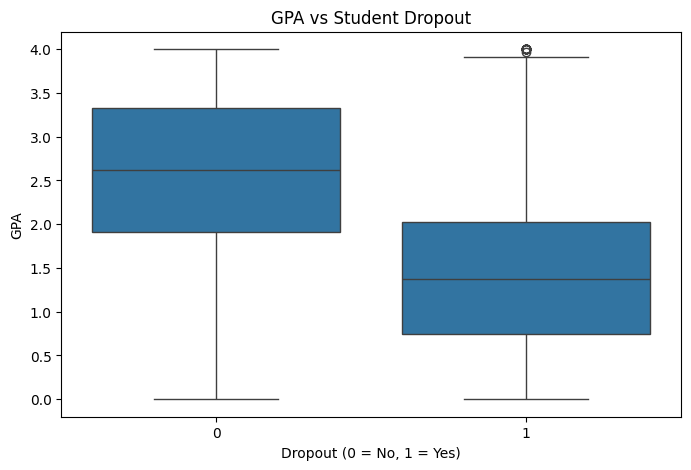

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='Dropout', y='GPA', data=df)

plt.title('GPA vs Student Dropout')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('GPA')
plt.show()

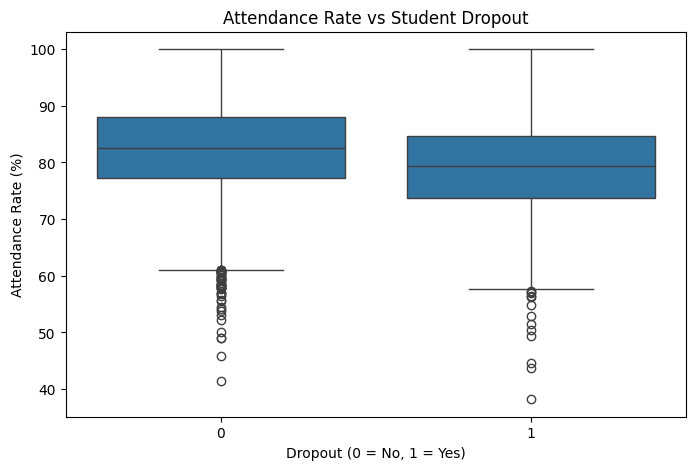

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='Dropout', y='Attendance_Rate', data=df)

plt.title('Attendance Rate vs Student Dropout')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('Attendance Rate (%)')
plt.show()

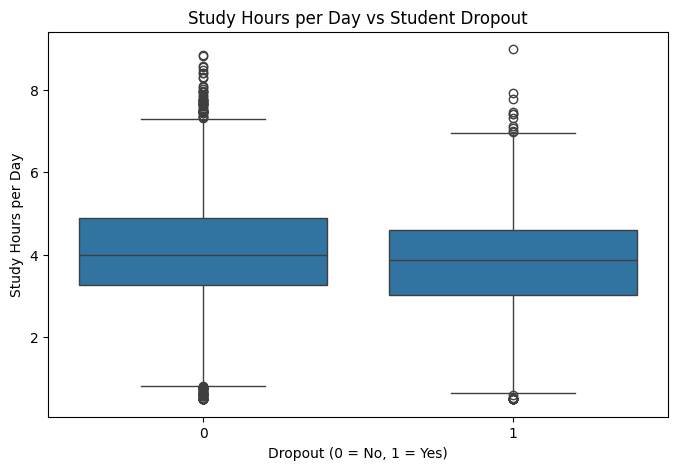

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='Dropout', y='Study_Hours_per_Day', data=df)

plt.title('Study Hours per Day vs Student Dropout')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('Study Hours per Day')
plt.show()

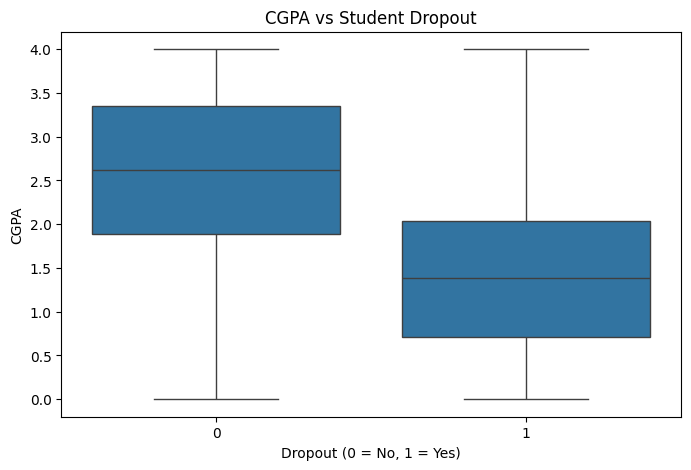

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='Dropout', y='CGPA', data=df)

plt.title('CGPA vs Student Dropout')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('CGPA')
plt.show()

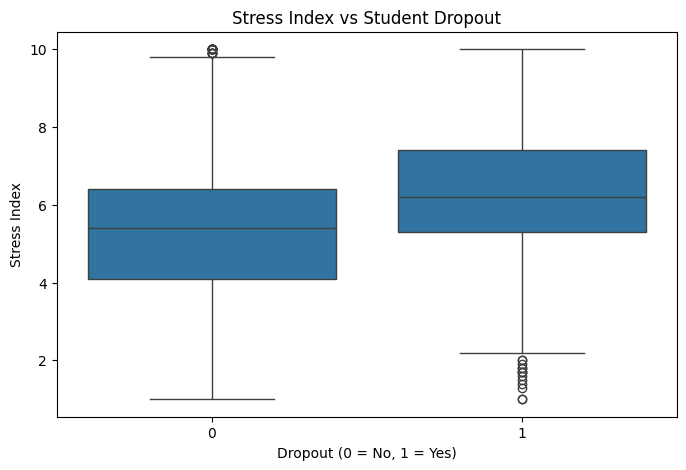

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='Dropout', y='Stress_Index', data=df)

plt.title('Stress Index vs Student Dropout')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('Stress Index')
plt.show()

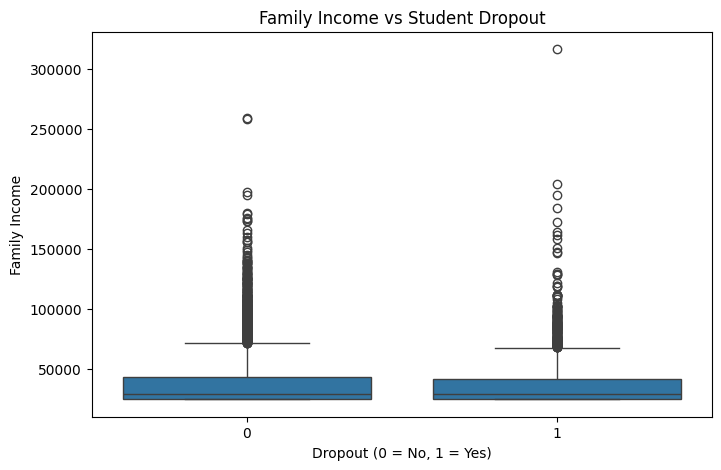

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='Dropout', y='Family_Income', data=df)

plt.title('Family Income vs Student Dropout')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('Family Income')
plt.show()

## Important Observations

1. Students with lower GPA and CGPA appear more frequently in the dropout group.
2. Dropout students generally show slightly lower attendance rates.
3. Higher stress levels are associated with higher dropout occurrence.
4. Study hours show similar distributions between dropout and non-dropout students.
5. Family income does not show a clear visual relationship with dropout status.
6. The dataset contains more non-dropout students than dropout students, indicating class imbalance.

**Feature Selection**

In [33]:
X = df.drop(columns=['Dropout', 'Student_ID'])
y = df['Dropout']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 24)
Target Shape: (10000,)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 24)
X_test: (2000, 24)
y_train: (8000,)
y_test: (2000,)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (8000, 24)
X_test_scaled shape: (2000, 24)


In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [37]:
y_pred = model.predict(X_test_scaled)

print("Predictions:", y_pred[:20])
print("Total Predictions:", len(y_pred))

Predictions: [0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0]
Total Predictions: 2000


In [38]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,1,1
4,1,0
5,1,1
6,1,0
7,0,0
8,0,0
9,1,1


In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8135
Accuracy (%): 81.35


In [40]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision:", precision)
print("Precision (%):", precision * 100)

Precision: 0.6433566433566433
Precision (%): 64.33566433566433


In [41]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)
print("Recall (%):", recall * 100)

Recall: 0.4043956043956044
Recall (%): 40.43956043956044


In [42]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1-Score:", f1)
print("F1-Score (%):", f1 * 100)

F1-Score: 0.4966261808367072
F1-Score (%): 49.662618083670715


In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1443  102]
 [ 271  184]]


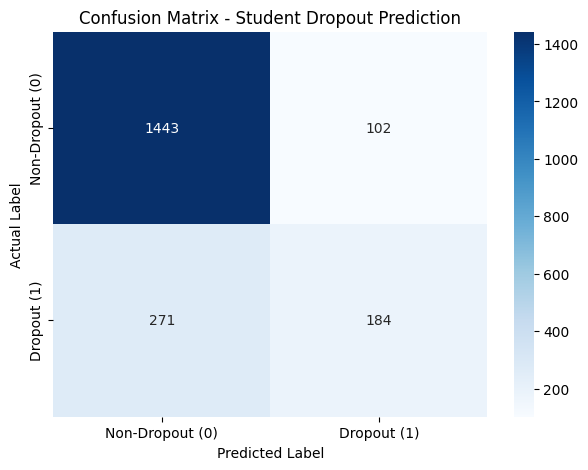

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Dropout (0)', 'Dropout (1)'],
    yticklabels=['Non-Dropout (0)', 'Dropout (1)']
)

plt.title('Confusion Matrix - Student Dropout Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

***Project Phase 5 — Student Dropout Prediction***

In [45]:
y_prob = model.predict_proba(X_test_scaled)

print("First 10 Prediction Probabilities:")
print(y_prob[:10])

First 10 Prediction Probabilities:
[[0.95035379 0.04964621]
 [0.82686581 0.17313419]
 [0.67834528 0.32165472]
 [0.26025325 0.73974675]
 [0.6710419  0.3289581 ]
 [0.29342327 0.70657673]
 [0.78499401 0.21500599]
 [0.81217898 0.18782102]
 [0.96431462 0.03568538]
 [0.49711347 0.50288653]]


***Project Phase 6 — Student Dropout Prediction***

In [46]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.89      1545
           1       0.64      0.40      0.50       455

    accuracy                           0.81      2000
   macro avg       0.74      0.67      0.69      2000
weighted avg       0.80      0.81      0.80      2000



In [47]:
from sklearn.metrics import roc_auc_score

y_prob_dropout = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_dropout)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8173775738824282


***Project Phase 7 — Student Dropout Prediction***

In [48]:
!pip install gradio

In [50]:
import gradio as gr
import pandas as pd

def predict_dropout(age, gender, family_income, internet, job, scholarship,
                    stress, gpa, study_hours, attendance, delay, travel,
                    sem_gpa, cgpa, semester, department, parental_edu):
    try:
        input_dict = {
            'Age': [age],
            'Gender': [gender],
            'Family_Income': [family_income],
            'Internet_Access': [internet],
            'Part_Time_Job': [job],
            'Scholarship': [scholarship],
            'Stress_Index': [stress],
            'GPA': [gpa],
            'Study_Hours_per_Day': [study_hours],
            'Attendance_Rate': [attendance],
            'Assignment_Delay_Days': [delay],
            'Travel_Time': [travel],
            'Semester_GPA': [sem_gpa],
            'CGPA': [cgpa],
            'Semester': [semester],
            'Department': [department],
            'Parental_Education': [parental_edu]
        }

        input_df = pd.DataFrame(input_dict)
        input_encoded = pd.get_dummies(input_df)

        if hasattr(model, 'feature_names_in_'):
            input_encoded = input_encoded.reindex(columns=model.feature_names_in_, fill_value=0)
        elif 'X' in globals():
            input_encoded = input_encoded.reindex(columns=X.columns, fill_value=0)

        input_scaled = scaler.transform(input_encoded)

        pred = model.predict(input_scaled)[0]
        prob = model.predict_proba(input_scaled)[0][1]

        prediction_text = "Student will Dropout" if pred == 1 else "Student will NOT Dropout"
        prob_text = f"{prob * 100:.2f}%"

        if prob >= 0.60:
            risk_text = "High Risk 🔴"
        elif prob >= 0.30:
            risk_text = "Medium Risk 🟡"
        else:
            risk_text = "Low Risk 🟢"

        return prediction_text, prob_text, risk_text

    except Exception as e:
        return f"Error: {str(e)}", "Error", "Error"

# Custom CSS to compact space and make elements fit in single view
custom_css = """
.gradio-container { max-width: 950px !important; margin: auto !important; }
.gr-button { background-color: #2b5c8f !important; color: white !important; font-weight: bold; }
"""

with gr.Blocks(css=custom_css, title="Student Dropout Prediction") as demo:
    gr.Markdown("<h2 style='text-align: center;'>🎓 Student Dropout Risk Prediction System</h2>")

    with gr.Row():
        # Left Side: Inputs organized in 3 Columns
        with gr.Column(scale=2):
            gr.Markdown("### 📋 Student Details")
            with gr.Row():
                age = gr.Number(label="Age", value=20)
                gender = gr.Dropdown(label="Gender", choices=["Male", "Female"], value="Male")
                family_income = gr.Number(label="Family Income", value=50000)

            with gr.Row():
                internet = gr.Dropdown(label="Internet Access", choices=["Yes", "No"], value="Yes")
                job = gr.Dropdown(label="Part-Time Job", choices=["Yes", "No"], value="No")
                scholarship = gr.Dropdown(label="Scholarship", choices=["Yes", "No"], value="No")

            with gr.Row():
                stress = gr.Number(label="Stress Index (1-10)", value=5)
                gpa = gr.Number(label="GPA", value=3.0)
                study_hours = gr.Number(label="Study Hours/Day", value=4)

            with gr.Row():
                attendance = gr.Number(label="Attendance Rate (%)", value=80)
                delay = gr.Number(label="Assignment Delay (Days)", value=2)
                travel = gr.Number(label="Travel Time (Mins)", value=30)

            with gr.Row():
                sem_gpa = gr.Number(label="Semester GPA", value=3.0)
                cgpa = gr.Number(label="CGPA", value=3.0)
                semester = gr.Dropdown(label="Semester", choices=["Year 1", "Year 2", "Year 3", "Year 4"], value="Year 2")

            with gr.Row():
                department = gr.Dropdown(label="Department", choices=["CS", "SE", "IT", "EE"], value="CS")
                parental_edu = gr.Dropdown(label="Parental Education", choices=["High School", "Bachelor", "Master", "PhD"], value="Bachelor")

            predict_btn = gr.Button("Predict Dropout Risk", variant="primary")

        # Right Side: Outputs
        with gr.Column(scale=1):
            gr.Markdown("### 📊 Prediction Result")
            output_pred = gr.Textbox(label="Prediction Result", interactive=False)
            output_prob = gr.Textbox(label="Dropout Probability", interactive=False)
            output_risk = gr.Textbox(label="Risk Level", interactive=False)

    # Trigger action
    predict_btn.click(
        fn=predict_dropout,
        inputs=[age, gender, family_income, internet, job, scholarship, stress, gpa,
                study_hours, attendance, delay, travel, sem_gpa, cgpa, semester, department, parental_edu],
        outputs=[output_pred, output_prob, output_risk]
    )

gr.close_all()
demo.launch(share=True)

/tmp/ipykernel_4314/725963717.py:62: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, title="Student Dropout Prediction") as demo:


Closing server running on port: 7860
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7d8144e291bbfa00a5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [52]:
import joblib

joblib.dump(model, "dropout_model.pkl")
joblib.dump(scaler, "dropout_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [55]:
from google.colab import files


files.download("dropout_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>